In [ ]:
!pip install mne
import numpy as np
import pandas as pd
import mne
from google.colab import drive

drive.mount('/content/drive')

# Path to your extracted Mendeley dataset
data_path = "/content/drive/MyDrive/An EEG Recordings Dataset for Mental Stress Detection.zip"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup and Data Extraction

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import mne
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths
zip_path = data_path  # Already defined in previous cell
extracted_path = '/content/eeg_dataset_extracted'

# Create directory for extracted data if it doesn't exist
if not os.path.exists(extracted_path):
    os.makedirs(extracted_path)

# Unzip the dataset
print(f"Unzipping dataset from {zip_path} to {extracted_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)
print("Dataset unzipped successfully!")

# Verify the extracted contents (optional)
print("Extracted contents:")
for root, dirs, files in os.walk(extracted_path):
    level = root.replace(extracted_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Unzipping dataset from /content/drive/MyDrive/An EEG Recordings Dataset for Mental Stress Detection.zip to /content/eeg_dataset_extracted...
Dataset unzipped successfully!
Extracted contents:
eeg_dataset_extracted/
    An EEG Recordings Dataset for Mental Stress Detection/
        Stroop Colour Word Test(SCWT)/
            2 (7).edf
            2 (2).edf
            2 (15).edf
            2 (20).edf
            2 (11).edf
            2 (14).edf
            2 (5).edf
            2 (12).edf
            2 (4).edf
            2 (9).edf
            2 (8).edf
            2 (23).edf
            2 (17).edf
            2 (6).edf
            2 (10).edf
            2 (22).edf
            2 (18).edf
            2 (13).edf
            2 (16).edf
            2 (21).edf
            2 (24).edf
            2 (19).edf
            2 (1).edf
            2 (3).edf
        Horrer Video Stimulation/
            002 (17).edf
            002 (20).edf
            002 (22).edf
            002 (2).edf
           

## Data Preprocessing

In [ ]:
import glob

# The base path where your folders are located based on your screenshot
base_extracted_path = '/content/eeg_dataset_extracted/An EEG Recordings Dataset for Mental Stress Detection'

# 1. Dynamically find all the category folders
# We use os.listdir to get folder names and filter out any hidden files
categories = [d for d in os.listdir(base_extracted_path) if os.path.isdir(os.path.join(base_extracted_path, d))]
categories.sort() # Sort alphabetically for consistency

print(f"Found {len(categories)} categories (classes):")
for i, cat in enumerate(categories):
    print(f"  {i}: {cat}")

# 2. Create a dictionary to map folder names to integer labels (0, 1, 2...)
label_map = {category: idx for idx, category in enumerate(categories)}

file_paths = []
labels = []

# 3. Loop through each folder and collect the .edf files
for category in categories:
    category_path = os.path.join(base_extracted_path, category)
    # Find all .edf files in this specific folder
    edf_files = glob.glob(os.path.join(category_path, '*.edf'))

    for file in edf_files:
        file_paths.append(file)
        labels.append(label_map[category])

print(f"\nTotal EEG files found: {len(file_paths)}")
print(f"Total labels assigned: {len(labels)}")

# Let's check the balance of our dataset
unique_labels, counts = np.unique(labels, return_counts=True)
print("\nDataset Balance:")
for label, count in zip(unique_labels, counts):
    print(f"  Class {label} ({categories[label]}): {count} files")

Found 5 categories (classes):
  0: Complex Mathematical Problem solving (CMPS)
  1: Horrer Video Stimulation
  2: Participants Listening to Relaxing Music
  3: Stroop Colour Word Test(SCWT)
  4: Trier Mental Challenge Test (TMCT)

Total EEG files found: 112
Total labels assigned: 112

Dataset Balance:
  Class 0 (Complex Mathematical Problem solving (CMPS)): 22 files
  Class 1 (Horrer Video Stimulation): 22 files
  Class 2 (Participants Listening to Relaxing Music): 20 files
  Class 3 (Stroop Colour Word Test(SCWT)): 24 files
  Class 4 (Trier Mental Challenge Test (TMCT)): 24 files


In [ ]:
import mne
import numpy as np

mne.set_log_level('WARNING')

# --- STEP 4a: Find Common Channels ---
print("Scanning files to find common channels...")
common_channels = None

for file_path in file_paths:
    try:
        # Load just the header to get channel names (super fast)
        raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
        ch_names = set(raw_temp.ch_names)

        if common_channels is None:
            common_channels = ch_names
        else:
            # Keep only the channels that exist in BOTH sets
            common_channels = common_channels.intersection(ch_names)
    except Exception as e:
        print(f"Could not read header for {file_path}")

common_channels = list(common_channels)
common_channels.sort() # Sort alphabetically so the order is strictly consistent

print(f"\nFound {len(common_channels)} common channels across all files.")
print(f"Channels kept: {common_channels[:5]}... (showing first 5)")

# --- STEP 4b: Preprocessing Function ---
def preprocess_edf(file_path, label, channels_to_keep):
    """Loads an EDF, enforces channel consistency, filters, and epochs."""
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    # 1. Enforce Channel Consistency
    raw.pick_channels(channels_to_keep)

    # 2. Enforce Sampling Rate Consistency (Standardize to 250 Hz)
    if raw.info['sfreq'] != 250.0:
        raw.resample(250.0)

    # 3. Filtering (0.5 to 45 Hz Bandpass, 50 Hz Notch)
    raw.filter(l_freq=0.5, h_freq=45.0, fir_design='firwin', verbose=False)
    raw.notch_filter(np.arange(50, 125, 50), verbose=False)

    # 4. Epoching (2-second windows, 1-second overlap)
    epochs = mne.make_fixed_length_epochs(raw, duration=2.0, overlap=1.0, preload=True, verbose=False)
    data = epochs.get_data(copy=False) # Shape: (n_epochs, n_channels, n_samples)

    # 5. Fast Z-score Normalization (Channel-wise)
    means = np.mean(data, axis=2, keepdims=True)
    stds = np.std(data, axis=2, keepdims=True)
    stds[stds == 0] = 1 # Prevent division by zero
    data = (data - means) / stds

    # 6. Create Labels
    n_epochs = data.shape[0]
    epoch_labels = np.full(n_epochs, label)

    return data, epoch_labels

# --- STEP 4c: Main Processing Loop ---
all_data = []
all_labels = []

print(f"\nStarting preprocessing for {len(file_paths)} files...")

for i, (file_path, label) in enumerate(zip(file_paths, labels)):
    try:
        data, epoch_labels = preprocess_edf(file_path, label, common_channels)
        all_data.append(data)
        all_labels.append(epoch_labels)

        if (i + 1) % 10 == 0 or (i + 1) == len(file_paths):
            print(f"  -> Processed {i + 1} / {len(file_paths)} files...")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Combine everything into the final X (features) and y (labels) arrays
X = np.concatenate(all_data, axis=0)
y = np.concatenate(all_labels, axis=0)

print("\n✅ Preprocessing Complete!")
print(f"Final Features Shape (X): {X.shape}  -> (Total Epochs, Channels, Samples)")
print(f"Final Labels Shape (y): {y.shape}")

Scanning files to find common channels...

Found 29 common channels across all files.
Channels kept: ['AF3', 'AF4', 'BATTERY', 'BATTERY_PERCENT', 'COUNTER']... (showing first 5)

Starting preprocessing for 112 files...
  -> Processed 10 / 112 files...
  -> Processed 20 / 112 files...
  -> Processed 30 / 112 files...
  -> Processed 40 / 112 files...
  -> Processed 50 / 112 files...
  -> Processed 60 / 112 files...
  -> Processed 70 / 112 files...
  -> Processed 80 / 112 files...
  -> Processed 90 / 112 files...
  -> Processed 100 / 112 files...
  -> Processed 110 / 112 files...
  -> Processed 112 / 112 files...

✅ Preprocessing Complete!
Final Features Shape (X): (35500, 29, 500)  -> (Total Epochs, Channels, Samples)
Final Labels Shape (y): (35500,)


## Model Definition: EEGNet

In [ ]:
import gc
import numpy as np

print(f"Original X memory size: {X.nbytes / (1024**3):.2f} GB")

# 1. Downcast to float32 (Instantly cuts memory usage in half!)
X = X.astype(np.float32)
y = y.astype(np.int32)

print(f"New X memory size: {X.nbytes / (1024**3):.2f} GB")

# 2. Delete the raw MNE objects and temporary lists we no longer need
try:
    del all_data
    del all_labels
except NameError:
    pass # Already deleted

# 3. Force Python to empty the trash
gc.collect()

print("Memory cleared! You are safe to run the training cell now.")

Original X memory size: 3.84 GB
New X memory size: 1.92 GB
Memory cleared! You are safe to run the training cell now.


New X shape for EEGNet: (35500, 29, 500, 1)

Starting 5-Fold Cross-Validation...

--- Training Fold 1 ---
Epoch 1/50
888/888 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.6575 - loss: 0.8569 - val_accuracy: 0.7856 - val_loss: 0.5619 - learning_rate: 0.0010
Epoch 2/50
888/888 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.7920 - loss: 0.5378 - val_accuracy: 0.8242 - val_loss: 0.4404 - learning_rate: 0.0010
Epoch 3/50
888/888 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8205 - loss: 0.4637 - val_accuracy: 0.8569 - val_loss: 0.3793 - learning_rate: 0.0010
Epoch 4/50
888/888 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8386 - loss: 0.4193 - val_accuracy: 0.8766 - val_loss: 0.3358 - learning_rate: 0.0010
Epoch 5/50
888/888 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8501 - loss: 0.3905 - val_accuracy: 0.8804 - val_loss: 0.3171 - learning_rate: 0.0010
Epoch 6/50
888/888 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8556 - loss: 0.3741 - val_accuracy: 0.8880 - val_loss: 0.2956 - l

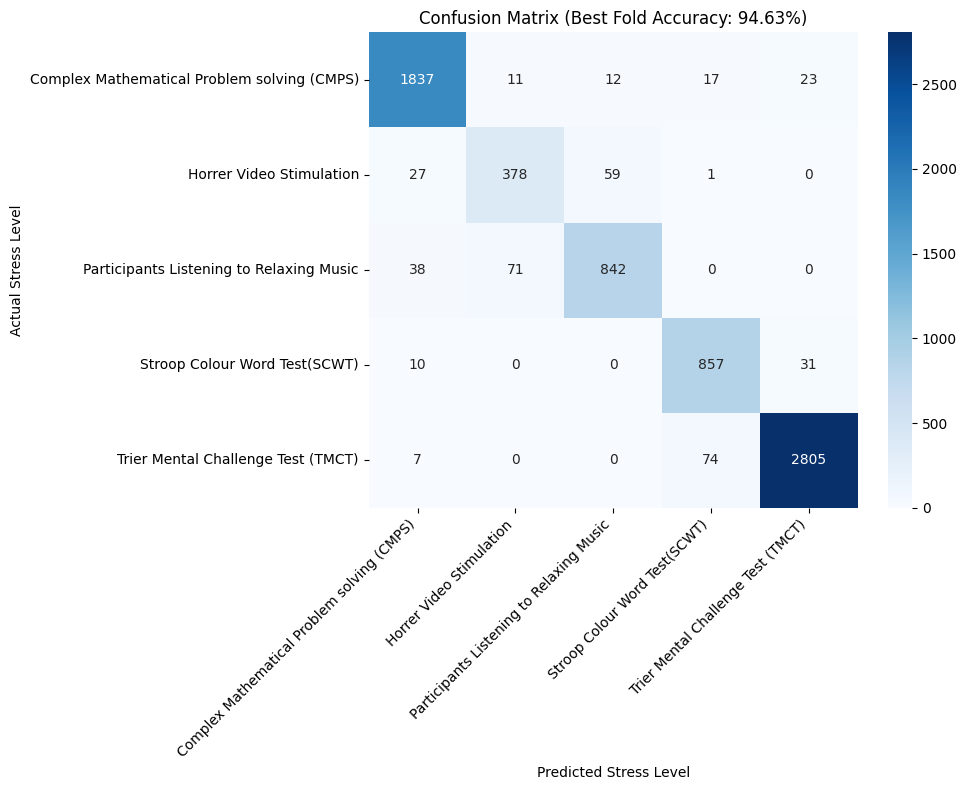

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.layers import Conv2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, DepthwiseConv2D
from tensorflow.keras.layers import BatchNormalization, Input, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reshape X for EEGNet
# EEGNet expects shape: (Trials, Channels, Samples, Kernels)
X_reshaped = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
print(f"New X shape for EEGNet: {X_reshaped.shape}")

# 2. Define the EEGNet Architecture
def EEGNet(nb_classes, Chans=29, Samples=500, dropoutRate=0.5):
    input1 = Input(shape=(Chans, Samples, 1))

    # Block 1: Temporal & Spatial Filters
    block1 = Conv2D(8, (1, 64), padding='same', use_bias=False)(input1)
    block1 = BatchNormalization()(block1)

    block1 = DepthwiseConv2D((Chans, 1), use_bias=False,
                             depth_multiplier=2,
                             depthwise_constraint=tf.keras.constraints.MaxNorm(1.))(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = Dropout(dropoutRate)(block1)

    # Block 2: Separable Convolution
    block2 = SeparableConv2D(16, (1, 16), use_bias=False, padding='same')(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = Dropout(dropoutRate)(block2)

    # Classification Block
    flatten = Flatten()(block2)
    dense = Dense(nb_classes, kernel_constraint=tf.keras.constraints.MaxNorm(0.25))(flatten)
    softmax = Activation('softmax')(dense)

    return Model(inputs=input1, outputs=softmax)

# 3. Stratified K-Fold Setup
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_no = 1
accuracies = []

# Training Parameters
epochs = 50
batch_size = 32

# Callbacks to prevent overfitting and optimize learning rate
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

print("\nStarting 5-Fold Cross-Validation...")

# We will store the actuals and predictions of the best fold for our confusion matrix
best_fold_acc = 0
best_y_true = []
best_y_pred = []

for train_index, test_index in skf.split(X_reshaped, y):
    print(f"\n--- Training Fold {fold_no} ---")

    # Split data
    X_train, X_test = X_reshaped[train_index], X_reshaped[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Initialize Model
    model = EEGNet(nb_classes=5, Chans=29, Samples=500)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train
    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[early_stop, lr_scheduler],
                        verbose=1)

    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    accuracies.append(acc)
    print(f"Fold {fold_no} Accuracy: {acc * 100:.2f}%")

    # Save predictions for the best fold to generate the confusion matrix later
    if acc > best_fold_acc:
        best_fold_acc = acc
        best_y_true = y_test
        best_y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    fold_no += 1

print(f"\n✅ Cross-Validation Complete!")
print(f"Average Accuracy across {n_splits} folds: {np.mean(accuracies) * 100:.2f}%")

# 4. Plotting the Confusion Matrix of the Best Fold
plt.figure(figsize=(10, 8))
cm = confusion_matrix(best_y_true, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title(f'Confusion Matrix (Best Fold Accuracy: {best_fold_acc * 100:.2f}%)')
plt.ylabel('Actual Stress Level')
plt.xlabel('Predicted Stress Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("\n--- Final Classification Report ---")
# Generate the report using the actual category names
report = classification_report(best_y_true, best_y_pred, target_names=categories)
print(report)


--- Final Classification Report ---
                                             precision    recall  f1-score   support

Complex Mathematical Problem solving (CMPS)       0.96      0.97      0.96      1900
                   Horrer Video Stimulation       0.82      0.81      0.82       465
   Participants Listening to Relaxing Music       0.92      0.89      0.90       951
              Stroop Colour Word Test(SCWT)       0.90      0.95      0.93       898
         Trier Mental Challenge Test (TMCT)       0.98      0.97      0.98      2886

                                   accuracy                           0.95      7100
                                  macro avg       0.92      0.92      0.92      7100
                               weighted avg       0.95      0.95      0.95      7100



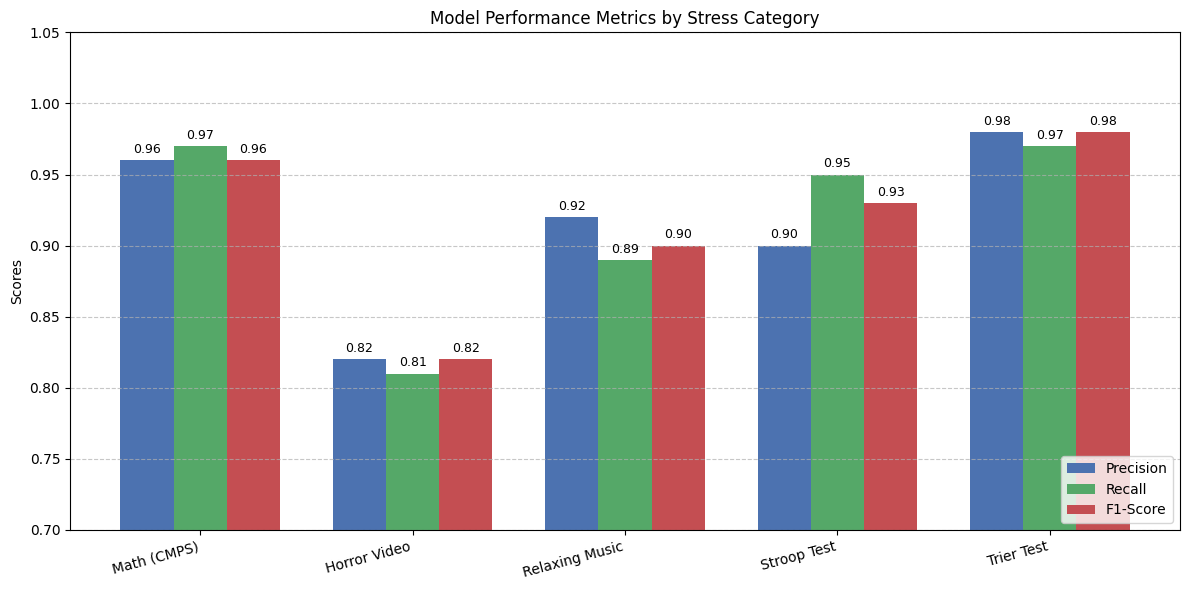

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from your classification report
categories = ['Math (CMPS)', 'Horror Video', 'Relaxing Music', 'Stroop Test', 'Trier Test']
precision = [0.96, 0.82, 0.92, 0.90, 0.98]
recall = [0.97, 0.81, 0.89, 0.95, 0.97]
f1_scores = [0.96, 0.82, 0.90, 0.93, 0.98]

# Set up the bar locations and width
x = np.arange(len(categories))
width = 0.25

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Draw the bars
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4C72B0')
rects2 = ax.bar(x, recall, width, label='Recall', color='#55A868')
rects3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#C44E52')

# Add labels, title, and formatting
ax.set_ylabel('Scores')
ax.set_title('Model Performance Metrics by Stress Category')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15, ha="right")
ax.legend(loc='lower right')
ax.set_ylim([0.7, 1.05]) # Set Y limit to highlight the differences nicely
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact numbers on top of the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

In [ ]:
# Save the model to a single file
model.save("/content/drive/MyDrive/EEG_Stress_Project/final_eegnet_model.keras")
print("Model saved successfully!")

Model saved successfully!
